# DS 542 Fall 2025 Project 2

Your task for this project to design and train a convolutional neural network classifying pictures of butterflies from [iNaturalist](https://www.inaturalist.org) by species.


## Background

The iNaturalist project crowdsources observations of wildlife including images, location, timestamp, and species identification.

Here is an example image from [an observation of a Monarch butterfly](https://www.inaturalist.org/observations/231456432).

![Danaus plexippus plexippus](https://inaturalist-open-data.s3.amazonaws.com/photos/411089128/medium.jpeg)


## Data

For this project, observations and images for many butterfly species were collected in a GitHub repository.

  https://github.com/DL4DS/butterflies

**Checking out this repository requires about 21GB of disk space.**
This repository is checked out on the Shared Compute Cluster (SCC) at `/projectnb/dl4ds/materials/datasets/butterflies`.

## Outline

1. Visualize species distribution and prepare to classify top 9 species.
2. Implement Torch DataSet and DataLoader objects to simplify data access.
3. Define model structure and select an appropriate loss function.
4. Implement a training loop and explain your choices.
5. Predict species for the test set.

## Modules

In [19]:
import pandas as pd
import torch

# Add any other imports you need

import os
import numpy as np
import pandas as pd
import torch

from PIL import Image
from collections import Counter
import matplotlib.pyplot as plt

from torch import nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

data_dir = os.path.join(os.getcwd(), "butterflies")
print(data_dir)

c:\Users\AT_Field\Desktop\DL-2026-Spring\hw\project2\butterflies


In [20]:
torch.manual_seed(42)
np.random.seed(42)

torch.backends.cudnn.benchmark = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Part 1: Visualize species distribution and prepare to classify top 9 species.

### Plot a histogram of species in the training data set.

Don't worry about cleaning up possible duplicates.
Just use the species names as is.

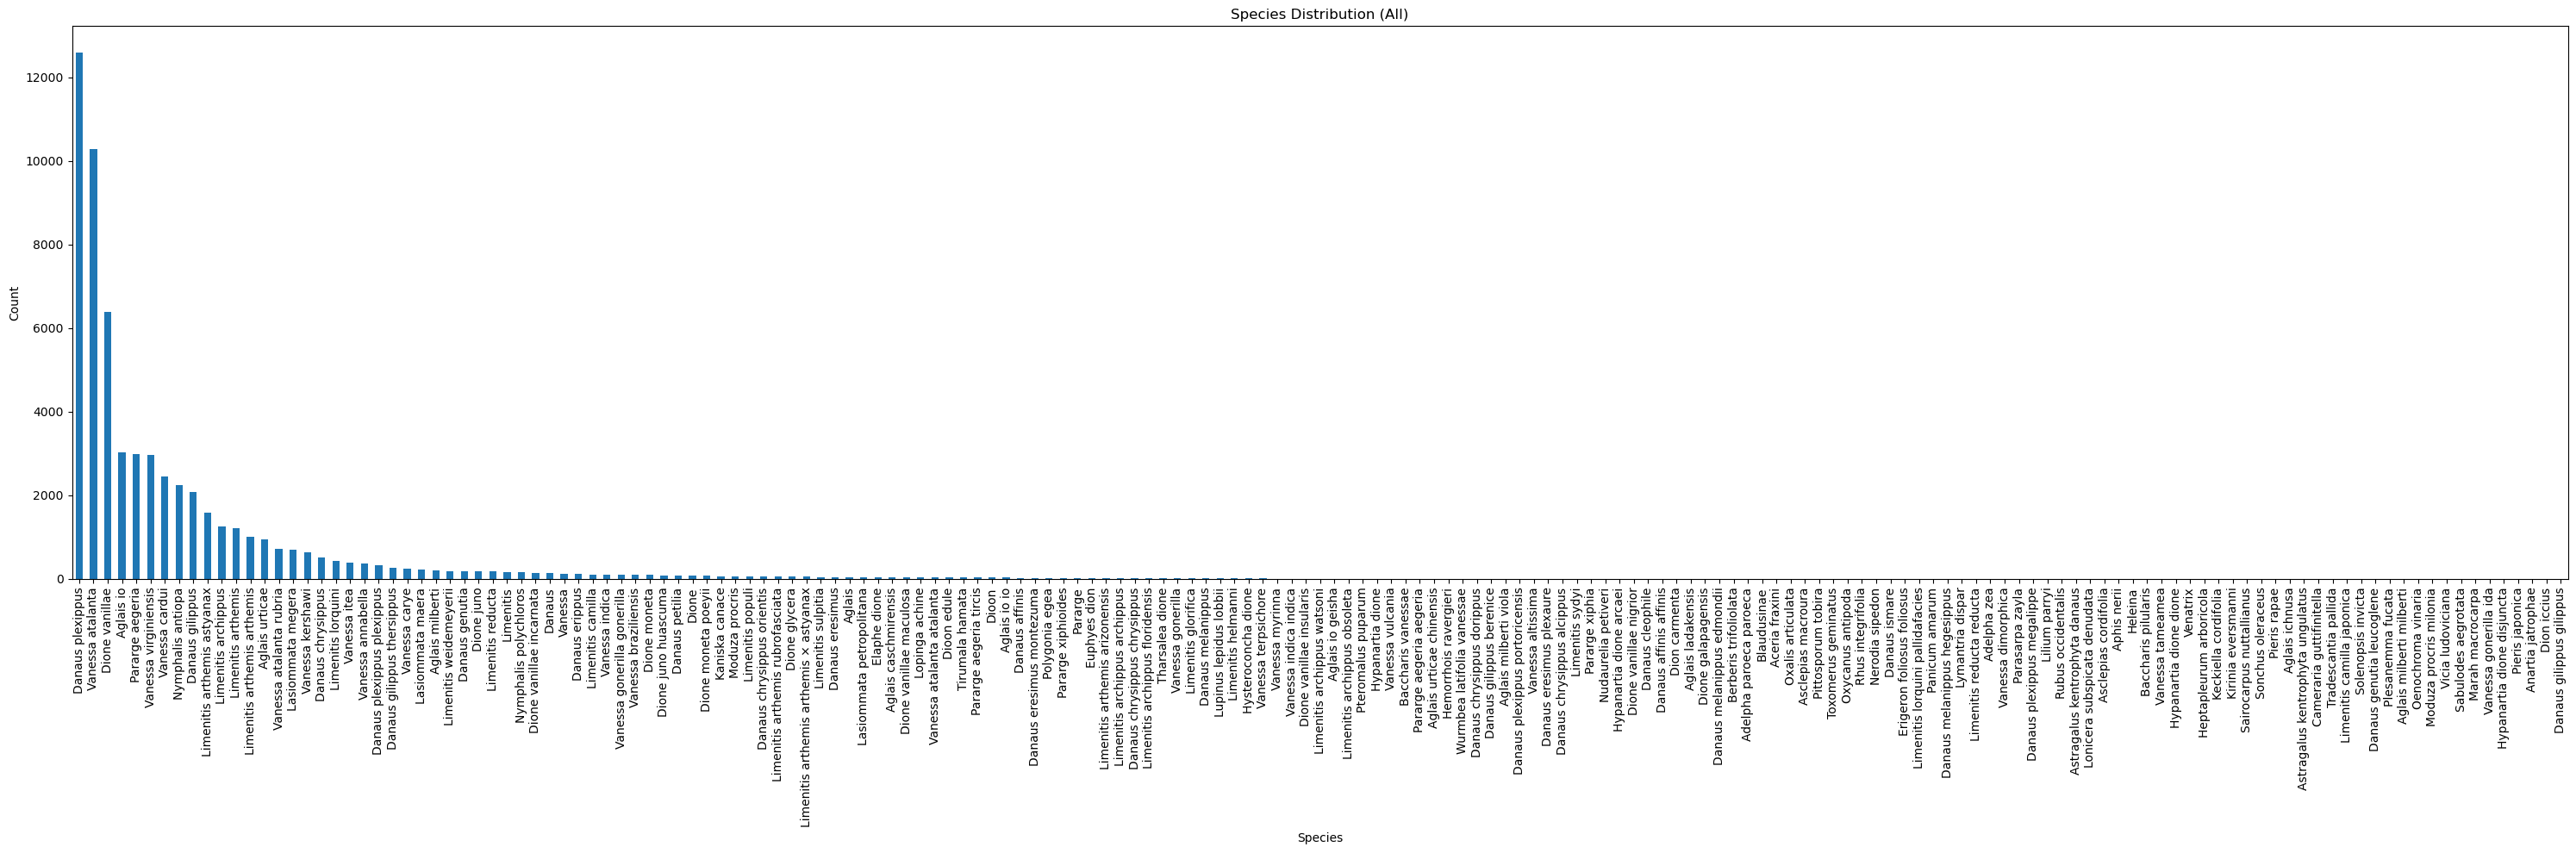

In [21]:
# YOUR CHANGES HERE
# training data analysis
train_df = pd.read_csv(os.path.join(data_dir, "train.csv"))

species_counts = train_df["scientific_name"].value_counts()

plt.figure(figsize=(30, 10))
species_counts.plot(kind="bar")
plt.title("Species Distribution (All)")
plt.xlabel("Species")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


### Plot a histogram of the top 9 species plus an "Other" category for the other species.

Use the training data set again.

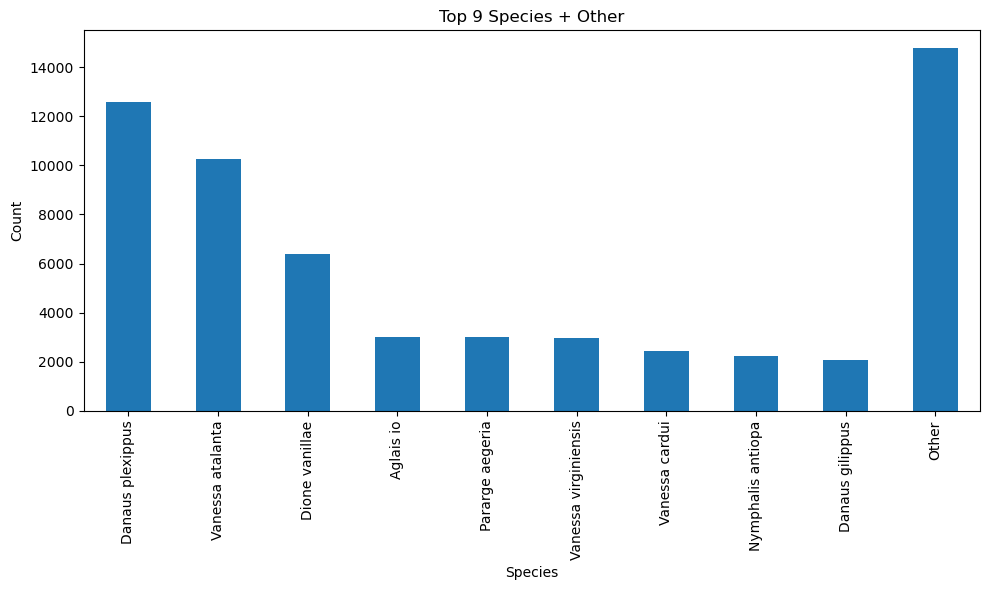

In [22]:
# YOUR CHANGES HERE
# get top 9 species
top_9 = species_counts.head(9).index.tolist()

# create new column for top 9 species + Other
train_df["species_grouped"] = train_df["scientific_name"].apply(
    lambda x: x if x in top_9 else "Other"
)

# reorder the labels for plotting
grouped_counts = train_df["species_grouped"].value_counts()
ordered_labels = top_9 + ["Other"]
grouped_counts = grouped_counts.reindex(ordered_labels)

plt.figure(figsize=(10, 6))
grouped_counts.plot(kind="bar")
plt.title("Top 9 Species + Other")
plt.xlabel("Species")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Write files "train-onehot.csv" and "validation-onehot.csv".

These will facilitate your data management later.
The columns for both files should be `uuid` and `image_path` from either "train.csv" or "validation.csv", followed by the top 9 species in the training data set in order, followed by `other`.
The values for the species and `other` columns should all be zero or one.

In [23]:
# YOUR CHANGES HERE
val_df = pd.read_csv(os.path.join(data_dir, "validation.csv"))

# NOTE: top_9 comes from the training set, we want to use the same grouping for validation
def create_onehot(df, top_9):
    df = df.copy()
    
    # assign label (top 9 or other)
    df["species_grouped"] = df["scientific_name"].apply(
        lambda x: x if x in top_9 else "other"
    )
    
    # create one-hot columns
    columns = top_9 + ["other"]
    
    for col in columns:
        df[col] = (df["species_grouped"] == col).astype(int)
    
    # select final columns
    df_final = df[["uuid", "image_path"] + columns]
    
    return df_final

# create one-hot datasets
train_onehot = create_onehot(train_df, top_9)
val_onehot = create_onehot(val_df, top_9)

# save
train_onehot.to_csv(os.path.join(data_dir, "train-onehot.csv"), index=False)
val_onehot.to_csv(os.path.join(data_dir, "validation-onehot.csv"), index=False)

Submit "train-onehot.csv" and "validation-onehot.csv" in Gradescope.

Comment: The onehot encoding into files could have been skipped and instead the onehot encoding could have been handled by the DataSet subclass in part 2.
The auto-grader will check your files and give points after verifying their contents.
You should test submitting early to make sure that you have prepared the intended files.

## Part 2: Implement Torch DataSet and DataLoader objects to simplify data access.

Implement Torch [DataSet](https://docs.pytorch.org/docs/stable/data.html#torch.utils.data.Dataset) and [DataLoader](https://docs.pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader) objects to separate data loading issues from the training logic.

Implement an appropriate DataSet subclass for the training and validation data.
The class constructor should take in a filename ("train.csv" or "validation.csv") and load the corresponding data.
The `__getitem__` method should return a tuple with a tensor of a single image data and a tensor with the onehot encoding of the target value.

In [24]:
# YOUR CHANGES HERE
print(top_9 + ["other"])

class ButterflyDataset(Dataset):
    def __init__(self, filename, data_dir, top_9=None, transform=None):
        self.data_dir = data_dir
        self.data = pd.read_csv(os.path.join(data_dir, filename))
        self.transform = transform

        # one-hot label columns (top 9 + other)
        self.top_9 = top_9
        self.label_columns = self.top_9 + ["other"]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_path = os.path.join(self.data_dir, row["image_path"])
        image = Image.open(img_path).convert("RGB")

        # Transform the image
        if self.transform:
            image = self.transform(image)
        
        # get species and group into top 9 or other
        species = row["scientific_name"]
        grouped_species = species if species in self.top_9 else "other"

        target = torch.tensor(
            [1 if col == grouped_species else 0 for col in self.label_columns],
            dtype=torch.float32
        )
        
        return image, target

# Transformation
# Change the size from 128x128 to 224x224
train_transform = transforms.Compose([
    transforms.Resize((192, 192)),
    transforms.RandomCrop(160),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((192, 192)),
    transforms.CenterCrop(160),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

['Danaus plexippus', 'Vanessa atalanta', 'Dione vanillae', 'Aglais io', 'Pararge aegeria', 'Vanessa virginiensis', 'Vanessa cardui', 'Nymphalis antiopa', 'Danaus gilippus', 'other']


Create a DataLoader object for the training data.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9980307..2.3935575].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8952821..2.3410363].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7695861..2.3785625].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6384109..2.5528543].


torch.Size([3, 160, 160])
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])
torch.Size([10])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..2.4831376].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


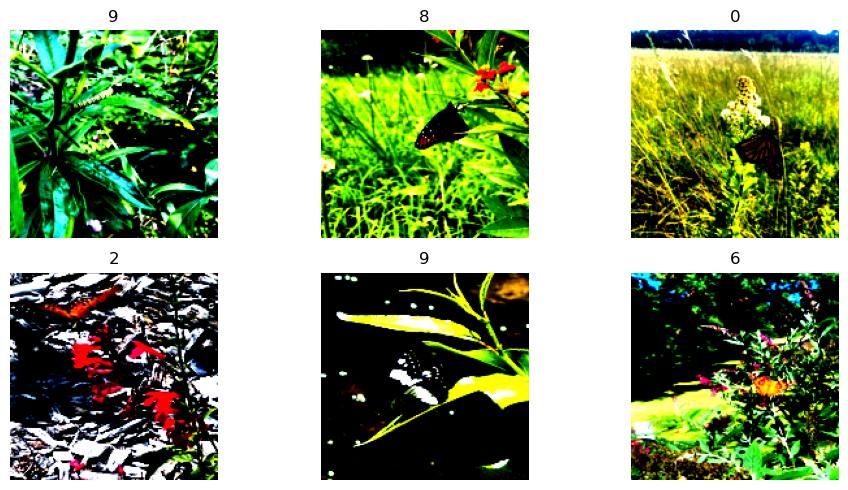

In [25]:
# YOUR CHANGES HERE
# NOTE: We already have the train_df and val_df loaded, we can use those to get the top_9 species and create the datasets
train_dataset = ButterflyDataset("train.csv", data_dir, top_9=top_9, transform=train_transform)
val_dataset = ButterflyDataset("validation.csv", data_dir, top_9=top_9, transform=val_transform)

# DataLoader
train_loader = DataLoader(
    train_dataset, batch_size=256, shuffle=True, num_workers=0,
    pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=256, shuffle=False, num_workers=0,
    pin_memory=True
)

# TEST PRINTING
image, target = train_dataset[0]
print(image.shape)
print(target)
print(target.shape)

plt.figure(figsize=(10, 5))

for i in range(6):
    image, target = train_dataset[i]
    
    img = image.permute(1, 2, 0).numpy()
    
    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(f"{target.argmax().item()}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Explain any non-default parameter choices you made for the DataLoader.

YOUR ANSWER HERE

...

## Part 3: Define model structure and select an appropriate loss function.

Implement the model class for your convolutional neural network.
The final output of your model should be a tensor of probabilities for each of the ten species choices.

> Hint 1: refer to [project 1](https://github.com/DL4DS/sp2026/blob/main/static_files/assignments/project1.ipynb) for an example, albeit it is most likely much to simple a model.

> Hint 2: think about models we discussed recently in class and start with one of the popular ones.

> Hint 3: this problem may benefit from starting with a model pre-trained on ImageNet in which you then finetune on this dataset.

In [26]:
# YOUR CHANGES HERE
from torchvision import models

class ButterflyModel(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        
        self.model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        
        in_features = self.model.fc.in_features
        self.model.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.model(x)
    
model = ButterflyModel(num_classes=10).to(device)

Explain your choices for the shapes in each convolutional layer of your model.

### ANS:
I used the pre-trained ResNet18 model. In ResNet18, the feature map size becomes smaller after the first convolution, max-pooling, and later residual stages. The spatial size is reduced by the initial stride-2 convolution, max-pooling, and the stride-2 residual blocks in layers 2, 3, and 4. This gradually shrinks the feature map while preserving important information, so the model moves from detailed local image features to compact high-level features before classification.

Explain your choices for the channels in each convolutional layer of your model.

### ANS:
The channels increase stage by stage in ResNet18. The model starts with 3 input channels for RGB images, uses 64 output channels in the first convolution, and then follows the standard ResNet18 progression of 64, 128, 256, and 512 in the residual stages. This increasing number of channels allows deeper layers to learn more complex and class-specific butterfly features, and the final fully connected layer maps the 512-dimensional feature vector to 10 output classes.

In [27]:
print(model.model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Pick and define a loss function for your model.
Feel free to use an existing Torch function.

In [28]:
# YOUR CHANGES HERE
label_names = top_9 + ["other"]

# number of samples per class (top 9 + other)
counts = train_dataset.data["scientific_name"].apply(
    lambda x: x if x in top_9 else "other"
).value_counts()

counts = [counts.get(c, 1) for c in label_names]

class_weights = 1.0 / torch.tensor(counts, dtype=torch.float32)
class_weights = class_weights / class_weights.sum() * len(class_weights)
class_weights = class_weights.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

Explain your choice of loss function.
One sentence should suffice.

### ANS:
As this is the multiclass classification problem with 10 possible classes, I choose CrossEntropyLoss as the loss function.

## Part 4: Implement a training loop and explain your choices.

Implement and run an appropriate training loop.
Plot accuracy and loss for the training and validation sets for each epoch.
Plot a summary of the gradients of your choice for each epoch.

In [29]:
# YOUR CHANGES HERE
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=2
)

# training settings
num_epochs = 6

# history
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# best model tracking
best_val_acc = 0.0
best_model_path = "best_model.pth"
scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))

for epoch in range(num_epochs):
    # -------------------
    # training
    # -------------------
    model.train()
    running_train_loss = 0.0
    correct_train = 0
    total_train = 0

    for batch_idx, (images, targets) in enumerate(train_loader):
        if batch_idx % 20 == 0:
            print(f"Epoch {epoch+1}/{num_epochs} | train batch {batch_idx}/{len(train_loader)}", flush=True)

        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        # one-hot -> class index
        target_idx = targets.argmax(dim=1)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
            outputs = model(images)
            loss = criterion(outputs, target_idx)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_train_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        correct_train += (preds == target_idx).sum().item()
        total_train += target_idx.size(0)

    epoch_train_loss = running_train_loss / total_train
    epoch_train_acc = correct_train / total_train

    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    # -------------------
    # validation
    # -------------------
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for batch_idx, (images, targets) in enumerate(val_loader):
            if batch_idx % 20 == 0:
                print(f"Epoch {epoch+1}/{num_epochs} | val batch {batch_idx}/{len(val_loader)}", flush=True)

            images = images.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            target_idx = targets.argmax(dim=1)

            with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
                outputs = model(images)
                loss = criterion(outputs, target_idx)

            running_val_loss += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)
            correct_val += (preds == target_idx).sum().item()
            total_val += target_idx.size(0)

    epoch_val_loss = running_val_loss / total_val
    epoch_val_acc = correct_val / total_val

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)
    scheduler.step(epoch_val_acc)

    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), best_model_path)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}"
    )

Epoch 1/6 | train batch 0/234
Epoch 1/6 | train batch 20/234
Epoch 1/6 | train batch 40/234
Epoch 1/6 | train batch 60/234
Epoch 1/6 | train batch 80/234
Epoch 1/6 | train batch 100/234
Epoch 1/6 | train batch 120/234
Epoch 1/6 | train batch 140/234
Epoch 1/6 | train batch 160/234
Epoch 1/6 | train batch 180/234
Epoch 1/6 | train batch 200/234
Epoch 1/6 | train batch 220/234
Epoch 1/6 | val batch 0/40
Epoch 1/6 | val batch 20/40
Epoch [1/6] | Train Loss: 1.3458, Train Acc: 0.6719 | Val Loss: 1.2070, Val Acc: 0.7167
Epoch 2/6 | train batch 0/234
Epoch 2/6 | train batch 20/234
Epoch 2/6 | train batch 40/234
Epoch 2/6 | train batch 60/234
Epoch 2/6 | train batch 80/234
Epoch 2/6 | train batch 100/234
Epoch 2/6 | train batch 120/234
Epoch 2/6 | train batch 140/234
Epoch 2/6 | train batch 160/234
Epoch 2/6 | train batch 180/234
Epoch 2/6 | train batch 200/234
Epoch 2/6 | train batch 220/234
Epoch 2/6 | val batch 0/40
Epoch 2/6 | val batch 20/40
Epoch [2/6] | Train Loss: 1.1204, Train Acc: 0

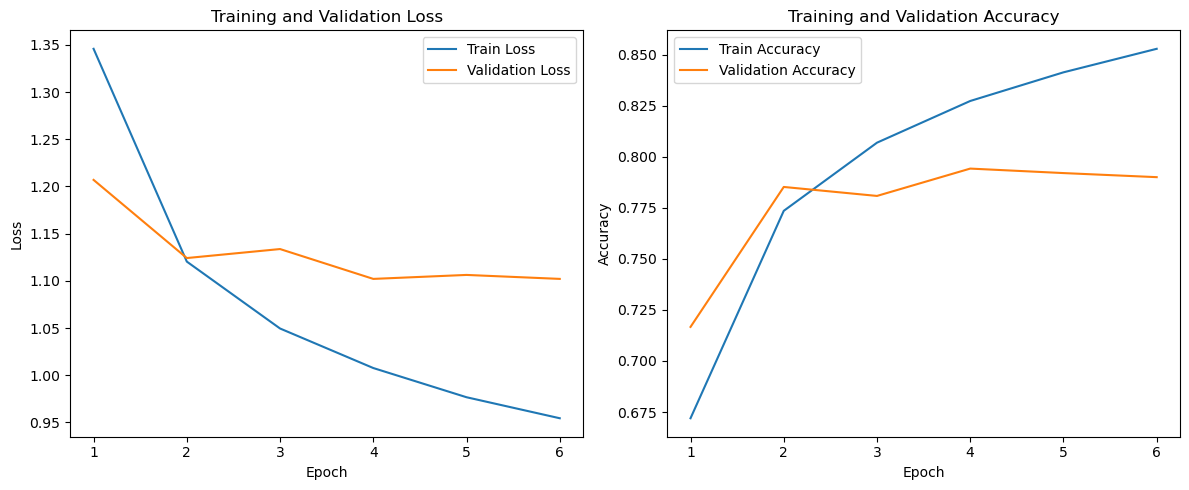

In [30]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label="Train Accuracy")
plt.plot(epochs, val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

## Part 5: Predict species for the test set.

Use your model to predict probabilities for each of the species choices.

In [31]:
# YOUR CHANGES HERE

# test dataset
class ButterflyTestDataset(Dataset):
    def __init__(self, filename, data_dir, transform=None):
        self.data_dir = data_dir
        self.df = pd.read_csv(os.path.join(data_dir, filename))
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.data_dir, row["image_path"])
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, row["uuid"]

# test loader
test_dataset = ButterflyTestDataset("test.csv", data_dir=data_dir, transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=0, pin_memory=True)

# predict
# NOTE: TTA (Test Time Augmentation)
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.eval()

all_probs = []
all_uuids = []

with torch.no_grad():
    for images, uuids in test_loader:
        images = images.to(device)
        flipped_images = torch.flip(images, dims=[3])

        with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)

            flipped_outputs = model(flipped_images)
            flipped_probs = torch.softmax(flipped_outputs, dim=1)

            probs = (probs + flipped_probs) / 2

        all_probs.append(probs.cpu())
        all_uuids.extend(uuids)

all_probs = torch.cat(all_probs, dim=0)

Save your predictions to "test-predictions.csv" with columns `uuid`, the top 9 species and `other`.

In [32]:
# YOUR CHANGES HERE
# save csv
columns = top_9 + ["other"]
pred_df = pd.DataFrame(all_probs.numpy(), columns=columns)
pred_df.insert(0, "uuid", all_uuids)

pred_df.to_csv("test-predictions.csv", index=False)
pred_df.head()

,uuid,Danaus plexippus,Vanessa atalanta,Dione vanillae,Aglais io,Pararge aegeria,Vanessa virginiensis,Vanessa cardui,Nymphalis antiopa,Danaus gilippus,other
0,262f0983-c2ac-46a2-84ba-edd938a848dc,0.011828,0.010256,0.738593,0.009020,0.014623,0.028329,0.015867,0.024892,0.124436,0.022156
1,58f79ba7-5eda-41c6-960c-75ea3e278f9f,0.005094,0.007919,0.813825,0.009531,0.014918,0.034983,0.021429,0.031889,0.046833,0.013579
2,a8fd457c-f463-440d-b575-227bc9bcf308,0.005124,0.005484,0.826574,0.013395,0.018528,0.027346,0.020160,0.032648,0.038782,0.011959
3,3aa46060-b298-4063-ba4b-3a8b779bb3bf,0.004597,0.021690,0.769979,0.013489,0.019743,0.029828,0.018025,0.032322,0.067671,0.022657
4,fea4c8a3-e788-4683-a311-82de6ae12366,0.009543,0.012718,0.759062,0.021259,0.025869,0.054583,0.019451,0.033903,0.025613,0.037999


Submit "test-predictions.csv" to Gradescope.

## Part 6: Submit Your Notebook

Submit your notebook to Gradescope.

## Follow Up

Make sure to check the immediate auto-grader feedback in Gradescope.
It will let you know if your file formats are correct and help you catch some avoidable mistakes.